# JetFighter_RL — Project overview (Phase 0)

**Teaching a simulated F-16 to fly with reinforcement learning, built from the physics up.**

This series of notebooks walks through the project one phase at a time. Each notebook is
short, runs on a laptop in a few minutes, and mixes three things:

* **the idea** — what the phase is for and why it was designed this way;
* **the equations** — only the ones that matter, with the notation used in the code;
* **small runnable examples** — calling the real project code, with plots.

| # | Notebook | What it shows |
|---|---|---|
| 0 | `00_project_overview` | Goal, method, repository layout, conventions, results at a glance |
| 1 | `01_physics_foundations` | Reference frames, quaternions, standard atmosphere, RK4 integrator |
| 2 | `02_point_mass_3dof` | A fast "point-mass" aircraft: forces, trim, flight envelope, a loop |
| 3 | `03_rigid_body_6dof` | The full rigid-body F-16 with NASA wind-tunnel tables, stability modes |
| 4 | `04_instruments_envelope` | Cockpit instruments, noisy sensors, energy, "you crashed" detection |
| 5 | `05_visualization` | Flight recording, deterministic replay, plots, Tacview 3D export |
| 6 | `06_classical_control` | PID, fly-by-wire, autopilot, LQR — the baseline the RL agent must beat |
| 7 | `07_gym_environment` | Turning the simulator into a Gymnasium RL environment |
| 8 | `08_rl_maneuvers` | Training PPO agents: curriculum, reward hacking, imitation, results |

## 1. The goal

The end goal of the project is an agent that **flies a fighter jet and evades a homing
missile**. That is a hard problem, so it is reached through a ladder of easier ones:

1. a trustworthy flight simulator (phases 1–5),
2. a classical autopilot as a reference (phase 6),
3. a reinforcement-learning environment (phase 7),
4. a curriculum of maneuvers learned by RL — stabilize, turn, navigate, loop (phase 8),
5. then a missile model and evasion training (phases 9–10, not started yet).

### The guiding principle: validate every layer before building on it

> *An RL agent trained on wrong physics learns to exploit the bugs, not to fly.*

RL optimizers are ruthless: if a sign error lets the aircraft gain energy for free, the
agent *will* find it. So every layer is checked against analytic solutions or published
F-16 data before the next one uses it — which is why the notebooks spend as much time on
validation plots as on the RL itself.

## 2. Architecture

```
                   ┌──────────────────────────────────────────────┐
  RL agent (PPO) ──►  action ∈ [-1, 1]^n                          │
       ▲           │     │ hierarchical: (n_z, roll rate, throttle)│
       │           │     ▼                                         │
       │           │  fly-by-wire inner loop (phase 6) ─► control  │
       │           │     │            surfaces (δe, δa, δr, thr)  │
       │           │     ▼                                         │
       │           │  aircraft dynamics 3-DOF / 6-DOF (phases 2-3)│
       │           │     │   ◄── atmosphere, frames, RK4 (phase 1)│
       │           │     ▼                                         │
       │           │  instruments + sensors + envelope (phase 4)  │
       │           └─────┼────────────────────────────────────────┘
       └── observation, reward, done (phase 7)  ──► Tacview/plots (phase 5)
```

Two aircraft models share the same interfaces, so everything above them (autopilot,
environment, agents) works with either:

* **3-DOF point mass** — very fast, used to prototype RL tasks;
* **6-DOF rigid body** — realistic, driven by its actual control surfaces, using the
  F-16 aerodynamic tables published by NASA (Stevens & Lewis).

## 3. Key design decisions

The roadmap keeps a decision log. The most important entries:

| Decision | Why |
|---|---|
| **F-16** as the reference aircraft (not F-22) | Its aerodynamic data is public (NASA TP-1538), so the 6-DOF model uses real wind-tunnel tables |
| **Quaternions** for attitude, Euler angles only for display | Euler angles are singular at ±90° pitch — exactly where a loop goes |
| **Hierarchical agent first, direct surface control later** | Commanding load factor and roll rate is far easier to learn than raw elevator/aileron; it validates the whole RL pipeline before the hard version |
| **Crash penalty = fixed + worst cost of all remaining steps** | Otherwise, far from the target, crashing was *cheaper* than continuing to fly |
| **Zero action = hold the current flight path** | With "zero = 1 g", the policy had to output 1/cos(bank) to two decimals just to not descend in a turn |
| **Gravity direction instead of Euler angles in the observation** | Euler angles flip by 180° when passing the vertical; a looping agent "thought it was inverted" and stopped |

Several of these were discovered *by watching trajectories*, not by looking at reward curves
— a recurring theme in notebook 8.

## 4. Conventions

Consistency is enforced across the whole code base (see the README):

| Topic | Convention |
|---|---|
| Units | **SI everywhere** internally; conversions only at the boundaries |
| Angles | **Radians** internally; degrees only for display and config files |
| Inertial frame | **NED** (North-East-Down), flat Earth; altitude $h = -z$ |
| Body frame | **FRD**: $x$ out the nose, $y$ out the right wing, $z$ down |
| Attitude | Unit quaternion $q = [q_0, q_1, q_2, q_3]$ (scalar first), $v_{ned} = C_{nb}(q)\,v_{body}$ |
| Time step | Physics at **100 Hz** with RK4; the agent decides at 10–50 Hz |
| Matrix names | $C_{ab}$ maps a vector from frame $b$ to frame $a$ |

## 5. The repository in numbers

Let's look at the actual package. Each sub-package maps to one or more phases.

In [1]:
%matplotlib inline
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from jetfighter.viz.style import INK, INK_2, SERIES, apply_style

apply_style()
plt.rcParams["figure.dpi"] = 110
ROOT = Path.cwd().parent  # notebooks/ -> repository root

PHASES = {
    "core": "1 · frames, atmosphere, integrators",
    "aircraft": "2-4 · 3-DOF / 6-DOF models, instruments",
    "viz": "5 · recording, plots, Tacview",
    "control": "6 · PID, fly-by-wire, autopilot, LQR",
    "envs": "7 · Gymnasium environment, tasks",
    "rl": "8 · training, imitation, transfer",
}
rows = []
for pkg, phase in PHASES.items():
    files = sorted((ROOT / "src/jetfighter" / pkg).rglob("*.py"))
    lines = sum(len(f.read_text(encoding="utf-8").splitlines()) for f in files)
    rows.append((pkg, phase, len(files), lines))
print(f"{'package':<10}{'phase · content':<44}{'files':>6}{'lines':>8}")
for pkg, phase, n, lines in rows:
    print(f"{pkg:<10}{phase:<44}{n:>6}{lines:>8}")
print(f"{'total':<54}{sum(r[2] for r in rows):>6}{sum(r[3] for r in rows):>8}")

package   phase · content                              files   lines
core      1 · frames, atmosphere, integrators              5     790
aircraft  2-4 · 3-DOF / 6-DOF models, instruments         12    2203
viz       5 · recording, plots, Tacview                    6     915
control   6 · PID, fly-by-wire, autopilot, LQR             6     568
envs      7 · Gymnasium environment, tasks                10    1944
rl        8 · training, imitation, transfer                8    1022
total                                                     47    7442


### Tooling

* `pyproject.toml` + [uv](https://docs.astral.sh/uv/) for dependencies, with optional extras
  (`[rl]` for PyTorch/Stable-Baselines3, `[viz]` for pygame);
* `ruff` for lint and formatting, run by `pre-commit` hooks;
* a GitHub Actions workflow that lints and runs the tests on Python 3.10 and 3.12;
* YAML configuration files for the aircraft, the sensors and every training experiment, so
  an experiment is reproducible from its config file alone.

The test suite is where the physics validation lives (analytic solutions, published values,
conservation laws). Running it:

In [2]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--color=no", "-p", "no:cacheprovider"],
    cwd=ROOT,
    capture_output=True,
    text=True,
)
print(result.stdout.strip().splitlines()[-1])

677 passed in 18.55s


## 6. Results at a glance

Each maneuver task has a **reference policy**: the classical autopilot from phase 6 (or a
scripted pilot for aerobatics). An agent is judged by its episode return relative to that
reference, and by a strict success criterion per task.

The numbers below are the best evaluated models from the training runs recorded in
`project_roadmap.md` (3-DOF model, hierarchical control, 1 seed). Notebook 8 explains how they
were obtained, including what went wrong along the way.

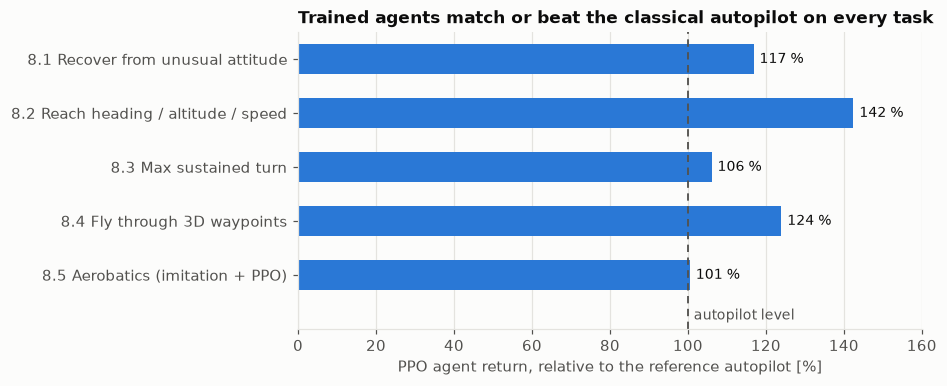

task                                      agent success  autopilot success
8.1 Recover from unusual attitude                 100%               100%
8.2 Reach heading / altitude / speed               90%               100%
8.3 Max sustained turn                            100%               100%
8.4 Fly through 3D waypoints                      100%                90%
8.5 Aerobatics (imitation + PPO)                  100%               100%


In [3]:
results = [
    # task, agent return, reference return, agent success, reference success
    ("8.1 Recover from unusual attitude", 20.8, 17.8, 1.00, 1.00),
    ("8.2 Reach heading / altitude / speed", 126.8, 89.0, 0.90, 1.00),
    ("8.3 Max sustained turn", 290.9, 274.2, 1.00, 1.00),
    ("8.4 Fly through 3D waypoints", 48.6, 39.2, 1.00, 0.90),
    ("8.5 Aerobatics (imitation + PPO)", 58.2, 57.9, 1.00, 1.00),
]
names = [r[0] for r in results][::-1]
ratio = np.array([100 * r[1] / r[2] for r in results])[::-1]

fig, ax = plt.subplots(figsize=(8.5, 3.4), layout="constrained")
bars = ax.barh(names, ratio, color=SERIES[0], height=0.55)
ax.axvline(100, color=INK_2, linewidth=1.2, linestyle=(0, (4, 3)))
ax.text(101.5, -0.75, "autopilot level", color=INK_2, fontsize=9, va="center")
ax.set_ylim(-1.0, len(names) - 0.5)
ax.set_axisbelow(True)
for b, v in zip(bars, ratio, strict=True):
    ax.text(
        v + 1.5, b.get_y() + b.get_height() / 2, f"{v:.0f} %", va="center", color=INK, fontsize=9
    )
ax.set_xlim(0, 160)
ax.set_xlabel("PPO agent return, relative to the reference autopilot [%]")
ax.set_title("Trained agents match or beat the classical autopilot on every task")
ax.grid(axis="y", visible=False)
plt.show()

print(f"{'task':<40}{'agent success':>15}{'autopilot success':>19}")
for name, _, _, s_agent, s_ref in results:
    print(f"{name:<40}{s_agent:>14.0%}{s_ref:>19.0%}")

A few things this chart does **not** show, and which the later notebooks discuss honestly:

* a higher return is not always a better flight — on 8.2 the agent scores higher but fails the
  strict "no overshoot" criterion more often than the autopilot;
* pure RL could not discover the loop, Immelmann and Split-S: the aerobatics agent starts
  from **imitation** of a scripted pilot;
* the harder version — the agent moving the control surfaces directly at 50 Hz, with no
  fly-by-wire to protect it — reaches 90–100 % success but 72–100 % of the hierarchical
  agent's return (step 8.6).

## 7. How to run these notebooks

```bash
uv venv && uv pip install -e ".[dev,rl]" jupyterlab
uv run jupyter lab notebooks/
```

Notebook 8 optionally reuses trained models from `runs/` (not versioned); when they are
missing it falls back to training a small agent live.